Name:
 - Daniel Besthof dfb2131
 - Harry Gavras hg2777
 - Matthew McCullough mlm2392
 - Ojas Arun oa2479

# Question I

Here we are given the following information: 
Standard model:
$$y_t = \mu + \sigma \epsilon_t$$
where $\epsilon_t$ is iid $\mathcal{N}(0,1)$. An extension with autocorrelation:
$$x_t = \rho x_{t-1} +\mu_t + \sigma_x \epsilon_t$$
In the second model, we have:
$$E[x_t] = \frac{\mu_x}{1-\rho}$$ and $$Var[x_t] = \frac{\sigma_x^2}{1-\rho^2}$$
We are also given, $\mu = 1%$, $\sigma = 5%$ and $\rho = 0.9$

Using this information we can solve for $\mu_x$ and $\sigma_x$, given that $E[x_t] =E[y_t]$ and $Var[x_t]=Var[y_t]$. Here we have:
$$E[y_t] = E[\mu + \sigma \epsilon_t] = \mu$$
so, 
$$\mu = E[x_t] \Rightarrow \mu = \frac{\mu_x}{1-\rho} \Rightarrow 0.01 = \frac{\mu_x}{1-0.9} \Rightarrow \mu_x = 0.001$$

Similarly,
$$Var[y_t] = Var[\mu + \sigma \epsilon_t] = \sigma^2$$
so, 
$$\sigma^2 = Var[x_t]  \Rightarrow \sigma^2 = \frac{\sigma_x^2}{1-\rho^2} \Rightarrow 0.05^2 = \frac{\sigma_x^2}{1-0.9^2} \Rightarrow \sigma_x = 0.0218$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
import seaborn as sns

## Part 1

In [2]:
N = 1000 #samples
T = 100 #observations
mu = 0.01
sigma = 0.05
rho = 0.9
mu_x = mu * (1 - rho)
sigma_x = np.sqrt(sigma ** 2 * (1 - rho **2))

E_xt = mu
Var_xt = sigma ** 2
Std_xt = np.sqrt(Var_xt)

np.random.seed(42)

### Unconditional distribution method

In [3]:
def compute_xt(N = N, T = T, E_xt  = E_xt, Std_xt = Std_xt):
    sampleEx = list()
    sampleStdx = list()

    for _ in range(N):
        epsilon_t = np.random.normal(0, 1, T)
        xt = np.zeros(T)
        x0 = np.random.normal(E_xt, Std_xt, 1)
        xt[0] = x0

        for ii in range(1, T):
            xt[ii] = rho * xt[ii - 1] + mu_x + sigma_x * epsilon_t[ii]

        sampleEx.append(np.mean(xt))
        sampleStdx.append(np.std(xt, ddof = 1))

    return sampleEx, sampleStdx

def compute_yt(N = N, T = T):
    sampleEy = list()
    sampleStdy = list()

    for _ in range(N):
        epsilon_t = np.random.normal(0, 1, T)

        yt = mu + sigma * epsilon_t

        sampleEy.append(np.mean(yt))
        sampleStdy.append(np.std(yt, ddof = 1))

    return sampleEy, sampleStdy



In [4]:
sample = np.linspace(1, N, N)
sampleEx, sampleStdx = compute_xt()
sampleEy, sampleStdy = compute_yt()
df = pd.DataFrame({'Sample #': sample,
                    'Sample mean (xt)': sampleEx,
                    'Sample STD (xt)': sampleStdx,
                    'Sample mean (yt)': sampleEy,
                    'Sample STD (yt)': sampleStdy})

/var/folders/3t/ztctgmqj21z2wypyf0h8mwp80000gn/T/ipykernel_73727/2609601656.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xt[0] = x0


### Burn-in method

In [5]:
def computeBurnIn_xt(N = N, T = T, E_xt = E_xt):
    burnSampleEx = list()
    burnSampleStdx = list()

    for n in range(N):
        
        X_0 = E_xt
        N_0 = 500
        for _ in range(N_0):
            epsilon_t = np.random.normal(0, 1, 1)
            X_0 = rho * X_0 + mu_x + sigma_x * epsilon_t

        epsilon_t = np.random.normal(0, 1, T)
        xt = np.zeros(T) 

        xt[0] = X_0
        for ii in range(1, T):
            xt[ii] = rho * xt[ii - 1] + mu_x + sigma_x * epsilon_t[ii]

        burnSampleEx.append(np.mean(xt))
        burnSampleStdx.append(np.std(xt, ddof = 1))

    return burnSampleEx, burnSampleStdx

In [6]:
burnSampleEx, burnSampleStdx = computeBurnIn_xt()
df_compare = pd.DataFrame({'Sample #': sample,
                    'Sample mean (uncond distrib)': sampleEx,
                    'Sample STD (uncond distrib)': sampleStdx,
                    'Sample mean (burn-in)': burnSampleEx,
                    'Sample STD (burn-in)': burnSampleStdx
                    })

/var/folders/3t/ztctgmqj21z2wypyf0h8mwp80000gn/T/ipykernel_73727/1418912634.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xt[0] = X_0


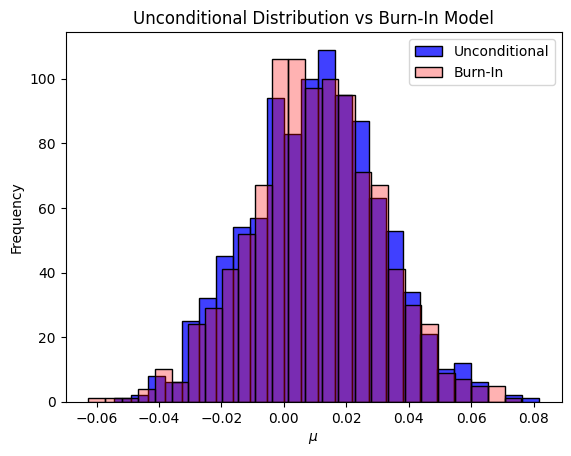

In [7]:
mean_ud = df_compare['Sample mean (uncond distrib)']
mean_bi = df_compare['Sample mean (burn-in)']

sns.histplot(x=mean_ud, color='blue', label='Unconditional')
sns.histplot(x=mean_bi, color='red', alpha=0.3, label='Burn-In')
plt.title('Unconditional Distribution vs Burn-In Model')
plt.xlabel('$\\mu$')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Part 2

In [8]:
mean_x = df['Sample mean (xt)']
mean_y = df['Sample mean (yt)']
std_x = df['Sample STD (xt)']
std_y = df['Sample STD (yt)']

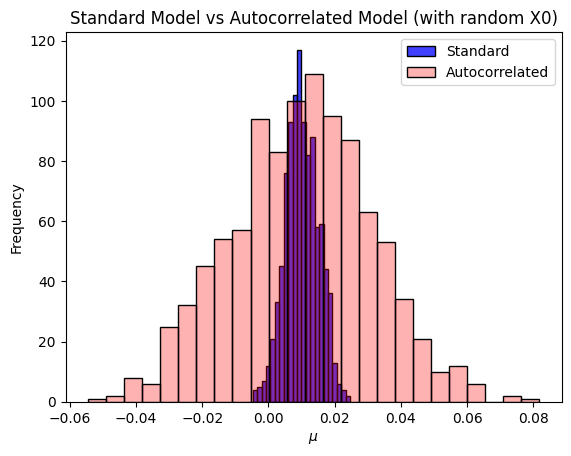

In [9]:
sns.histplot(x=mean_y, color='blue', label='Standard')
sns.histplot(x=mean_x, color='red', alpha=0.3, label='Autocorrelated')
plt.title('Standard Model vs Autocorrelated Model (with random X0)')
plt.xlabel('$\\mu$')
plt.ylabel('Frequency')
plt.legend()
plt.show()

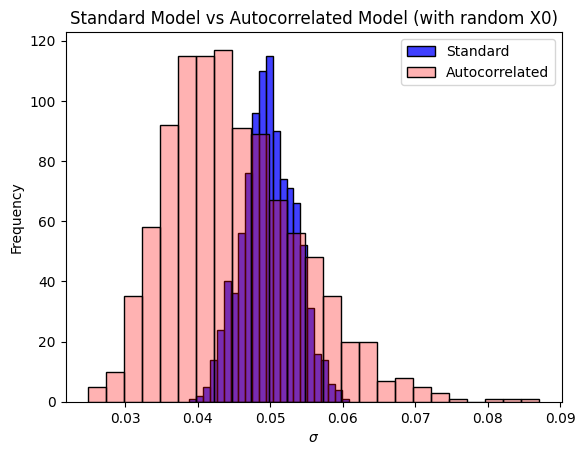

In [10]:
sns.histplot(x=std_y, color='blue', label='Standard')
sns.histplot(x=std_x, color='red', alpha=0.3, label='Autocorrelated')
plt.title('Standard Model vs Autocorrelated Model (with random X0)')
plt.xlabel('$\\sigma$')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [11]:
df_stds = pd.DataFrame({'xt': [np.std(mean_x), np.std(std_x)],
                        'yt': [np.std(mean_y), np.std(std_y)]}, 
                        index = ['Standard Deviation of Sample Mean', 'Standard Deviation of Sample STD'])
df_stds

,xt,yt
Standard Deviation of Sample Mean,0.021182,0.004974
Standard Deviation of Sample STD,0.009120,0.003645


As is shown above, autocorrelation is lowering our sampling precision. The SD on the autocorrelated model $x_t$'s mean $\mu$ is significantly higher than the standard model $y_t$. Looking at the histograms you can see that the autocorrelated model has a much less centered distribution. The standard error of the estimates are also much larger for the autocorrelated model for $\sigma$. Overall, the autocorrelated model has much higher sampling uncertainty. 

### Part 3

In [12]:
kurtosis_mean_x = kurtosis(mean_x)
kurtosis_std_x = kurtosis(std_x)
kurtosis_mean_y = kurtosis(mean_y)
kurtosis_std_y = kurtosis(std_y)

skewness_mean_x = skew(mean_x)
skewness_std_x = skew(std_x)
skewness_mean_y = skew(mean_y)
skewness_std_y = skew(std_y)

In [13]:
df_moments = pd.DataFrame({'xt': [kurtosis_mean_x, kurtosis_std_x, skewness_mean_x, skewness_std_x],
                        'yt': [kurtosis_mean_y, kurtosis_std_y, skewness_mean_y, skewness_std_y]}, 
                        index = ['Kurtosis of Sample Mean', 'Kurtosis of Sample STD','Skewness of Sample Mean', 'Skewness of Sample STD'])
df_moments

,xt,yt
Kurtosis of Sample Mean,-0.112970,-0.214075
Kurtosis of Sample STD,0.687122,-0.259289
Skewness of Sample Mean,0.005922,0.002667
Skewness of Sample STD,0.721591,0.054778


There is slightly less kurtosis in the standard model versus the autocorrelated model for the sample mean distribution. There is more kurtosis in the distribution for the sample standard deviation for the autocorrelated model. However, the distributions of the sample mean and sample standard deviation both have small excess or negative excess kurtosis. Both models have sample means that are slightly skewed to the right. The sample STD is highly skewed to the right on the autocorrelated model while the standard model has small right skew.

### Part 4

In [14]:
def effective_sample_size(T, rho):
    return T * (1 - rho) / (1 + rho)

print(f'Effective Sample Size Standard Model: {effective_sample_size(100, 0)}')
print(f'Effective Sample Size Autocorrelated Model: {effective_sample_size(100, 0.9)}')

Effective Sample Size Standard Model: 100.0
Effective Sample Size Autocorrelated Model: 5.263157894736842


From these simulations, we can see that there is less precision in the estimates for the sample mean and standard deviation in the autocorrelated model. The descriptive statistics are better behaved in the standard model, as is evident from the kurtosis and skew. Furthermore, the effective sample size of the autocorrelated model is only ~5, whereas the standard model is 100 which explains the distributions we found. This shows that in practice it is important to account for estimation uncertainty when working with a process with autocorrelation. 

# Question II

### 1.
The ACF for AR(2) is given by:
$$\rho_j = \frac{\gamma_j}{\gamma_0}$$

where $$\gamma_j = \phi_1\gamma_{j-1} + \phi_2 \gamma_{j-2}$$ for j>0, and $$\gamma_0 = \phi_1\gamma_{1} + \phi_2 \gamma_{2}+\sigma_{\epsilon}^2$$
for j=0.

Solving for $\gamma_0$ we get:
$$\gamma_0 = \frac{(1-\phi_2)\sigma_\epsilon^2}{(1+\phi_2) [(1-\phi_2)^2 - \phi_1^2]}$$

using this result, and the fact that $\gamma_{-j} = \gamma_j$ we can calculate the rest of the autocovariances of AR(2). 

Here $\phi_1 = 1.1$ and $\phi_2 = -0.25$.


In [15]:
lags = 20
phi1 = 1.1
phi2 = -0.25
sigmaEps = 1

def autocorrelation(phi1, phi2, lags = lags, sigmaEps = sigmaEps):
    gammas = np.zeros(lags + 1)
    gammas[0] = sigmaEps * (1-phi2) / ((1 + phi2) * ((1 - phi2) ** 2 - phi1 ** 2))
    gammas[1] = (phi1 / (1 - phi2)) * gammas[0]

    for ii in range(2, lags + 1):
        gammas[ii] = phi1 * gammas[ii - 1] + phi2 * gammas[ii - 2]

    rho = np.ones(lags + 1)
    for ii in range(1, lags + 1):
        rho[ii] = gammas[ii] / gammas[0]
    return rho

In [16]:
def bar_plot(rho, lags):
    L = np.arange(lags + 1)
    #L = np.linspace(1, lags, lags)
    fig, ax = plt.subplots()

    ax.bar(L, rho, width = 0.8)
    ax.set(xlim = (0, lags), xticks = L)
    ax.spines['bottom'].set_visible(True)

    plt.show()

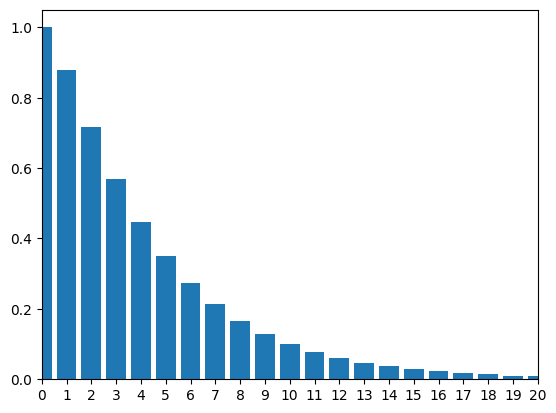

In [17]:
rho = autocorrelation(phi1, phi2)
bar_plot(rho, lags)

### 2. 
The second order difference equation for ACF is:
$$(1-\phi_1 L - \phi_2 L^2)\rho_j=0$$
This is equivalent to setting:
$$(1-\phi_1 x - \phi_2 x^2) = 0$$
and solving the quadratic equation. Here, we get:
$$x_{1,2} = \frac{1.1\pm\sqrt{0.21}}{0.5}$$
Therefore, we have $x_1 \approx 3.117$, $x_2 \approx 1.284$.
The characteristic roots, are therefore:
$$\omega_1 = x_1^{-1}=\frac{1}{3.117} = 0.321 < 1$$
and $$\omega_2 = x_2^{-1} = \frac{1}{1.284} = 0.779 < 1$$

Therefore, both of the characteristic roots are less than one in modulus, so the AR(2) is stationary.

### 3.

$$r_{t}-\mu =\phi _{1}\left( r_{t-1}-\mu \right) +\phi _{2}\left( r_{t-2}-\mu \right) +\varepsilon _{t}$$

$$=\phi _{1}\left[ \phi _{1}\left( r_{t-2}-\mu \right) +\phi _{2}\left( r_{t-3}-\mu \right) +\varepsilon _{t-1}\right] +\phi _{2}\left[ \phi _{1}\left( r_{t-3}-\mu \right) +\phi _{2}\left( r_{t-4}-\mu \right) +\varepsilon _{t-2}\right] +\varepsilon _{t}$$

$$=\phi _{1}^{2}\left( r_{t-2}-\mu \right) +\phi _{1}\phi _{2}\left( r_{t-3}-\mu \right) +\phi _{1}\varepsilon _{t-1}+\phi _{1}\phi _{2}\left( r_{t-3}-\mu \right) +\phi _{2}^{2}\left( r_{t-4}-\mu \right) +\phi _{2}\varepsilon _{t-2}+\varepsilon _{t}$$

$$=\phi _{1}^{2}\left( r_{t-2}-\mu \right) +\phi _{2}^{2}\left( r_{t-4}-\mu \right) +2\phi _{1}\phi _{2}\left( r_{t-3}-\mu \right) +\phi _{2}\varepsilon _{t-2}+\phi _{1}\varepsilon _{t-1}+\varepsilon _{t}$$

$$\begin{aligned}=\phi _{1}^{2}\left[ \phi _{1}\left( r_{t-3}-\mu \right) +\phi _{2}\left( r_{t-4}-\mu \right) +\varepsilon _{t-2}\right] +\phi _{2}^{2}\left[ \phi _{1}\left( r_{t-5}-\mu \right) +\phi _{2}\left( r_{t-6 }-\mu \right) +\varepsilon _{t-4}\right] \\
+2\phi _{1}\phi _{2}\left[ \phi _{1}\left( r_{t-4}-\mu \right) +\phi _{2}\left( r_{t-5}-\mu \right) +\varepsilon _{t-3}\right] \\
+\phi _{2}\varepsilon _{t-2}+\phi _{1}\varepsilon _{t-1}+\varepsilon _{t}\end{aligned}$$

$$\begin{aligned}=\phi _{1}^{3}\left( r_{t-3}-\mu \right) +\phi _{1}^{2}\phi _{2}\left( r_{t-4}-\mu \right) +\phi _{n}^{2}\varepsilon _{t-2}+\phi _{2}^{2}\phi _{n}\left( r_{t-5}-\mu \right) +\phi _{2}^{3}\left( r_{t-6}-\mu \right) +\phi _{2}^{2}\varepsilon _{t-4}\\
+2\phi _{1}^{2}\phi _{2}\left( t_{t-4}-\mu \right) +2\phi _{1}\phi _{2}^{2}\left( r_{t-5}-\mu \right) +2\phi _{1}\phi _{2}\varepsilon _{t-3}+\phi _{2}\varepsilon _{t-2}+\phi _{1}\varepsilon _{t-1}+\varepsilon _{t}\end{aligned}$$

$$\begin{aligned}=\phi _{1}^{3}\left( r_{t-3}-\mu \right) +3\phi _{1}^{2}\phi _{2}\left( r_{t-4}-\mu \right) +3\phi _{1}\phi _{2}^{2}\left( r_{t-5}-\mu \right) +\phi _{2}^{3}\left( r_{t-6}-\mu \right) +\phi _{1}^{2}\varepsilon _{t-2}\\
+\phi _{1}\varepsilon _{t-1}+2\phi _{1}\phi _{2}\varepsilon _{t-3}+\phi _{2}^{2}\varepsilon _{t-4}+\phi _{2}\varepsilon _{t-2}+\varepsilon _{t}\end{aligned}$$

By repeated substitution we get:

$$r_{t}-\mu =\sum ^{t+1}_{k=0}\begin{pmatrix}
t+1 \\
k
\end{pmatrix}\phi _{1}^{k}\phi _{2}^{t+1-k}\left( r_{-t-2+k}-\mu \right) +\sum ^{t}_{i=0}\sum ^{i}_{k=0}\begin{pmatrix}
i \\
k
\end{pmatrix}\phi _{1}^{k}\phi _{2}^{i-k}\varepsilon _{t-\left( 2i-k\right) }$$

Using this result we can calculate the dynamic multiplier of AR(2). In this case:

$$\frac{\partial[r_{t+6}-\mu]}{\partial \epsilon_t} = \frac{\partial[r_{6}-\mu]}{\partial \epsilon_0} = \phi_1^6 + 5\phi_1^4\phi_2 + 6\phi_1^2\phi_2^2 + \phi_2^3$$

In [18]:
dm6 = phi1 ** 6 + 5 * phi1 ** 4 * phi2 + 6 * phi1 ** 2 * phi2 ** 2 + phi2 ** 3

print(f'The dynamic multiplier for a shock that occurred 6 periods ago is {dm6:.5f}')

The dynamic multiplier for a shock that occurred 6 periods ago is 0.37956


### 4.

In [19]:
phi1 = 0.9
phi2 = 0.8

dm6 = phi1 ** 6 + 5 * phi1 ** 4 * phi2 + 6 * phi1 ** 2 * phi2 ** 2 + phi2 ** 3

print(f'The dynamic multiplier for a shock that occurred 6 periods ago is {dm6:.5f}')

The dynamic multiplier for a shock that occurred 6 periods ago is 6.77824


Following the same process as in question 2:
The second order difference equation for ACF is:
$$(1-\phi_1 L - \phi_2 L^2)\rho_j=0$$
This is equivalent to setting:
$$(1-\phi_1 x - \phi_2 x^2) = 0$$
and solving the quadratic equation. Here, we get:
$$x_{1,2} = \frac{0.9\pm\sqrt{4.01}}{-1.6}$$
Therefore, we have $x_1 \approx -1.81$, $x_2 \approx 0.69$.
The characteristic roots, are therefore:
$$\omega_1 = x_1^{-1}=\frac{1}{-1.81} = -0.55 < 1$$
and $$\omega_2 = x_2^{-1} = \frac{1}{0.69} = 1.45 > 1$$

Therefore, one of the characteristic roots are greater than one in modulus, so the AR(2) is not stationary.

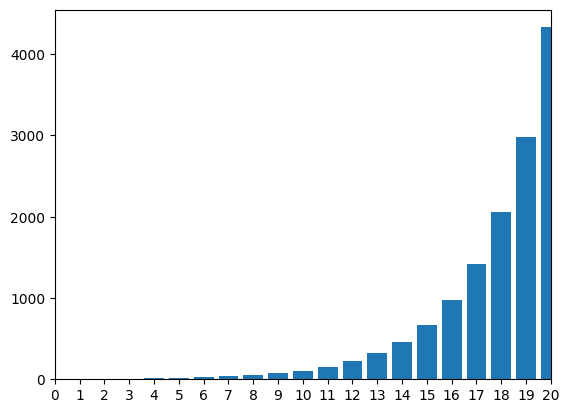

In [20]:
rho = autocorrelation(phi1, phi2)
bar_plot(rho, lags)

### 5.

In [21]:
lags = 60
x = np.zeros(lags + 3)
eps = np.zeros(lags + 3)
eps[2] = 1

for jj in range(2, lags + 3):
    x[jj] = 1.1 * x[jj - 1] - 0.25 * x[jj - 2] + eps[jj]

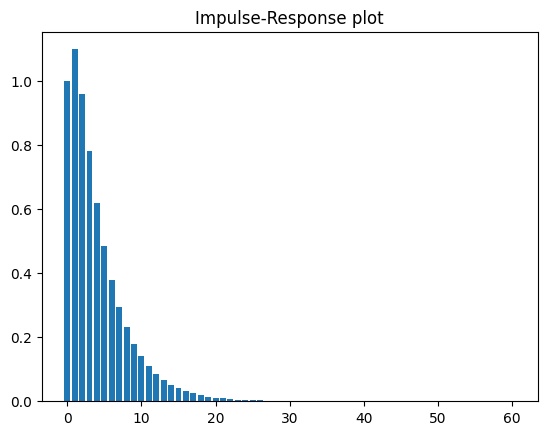

In [22]:
L = np.arange(lags + 1)
fig, ax = plt.subplots()

ax.bar(L, x[2:], width = 0.8)
#ax.set(xlim = (0, lags), xticks = L)
ax.spines['bottom'].set_visible(True)
plt.title('Impulse-Response plot')
plt.show()

In [23]:
lag = 8
print(f'The x value at lag = {lag - 2} is equal to {x[lag]:.5f}.')

The x value at lag = 6 is equal to 0.37956.


As we can see the value of $x_6 = 0.37956$ same as we calculated in question 3.

# Question III

### 1.

In [24]:
def random_walk(sigma, rho, r, mu, eps):
    for day in range(days):
        r[day] = mu + rho * r[day - 1] + sigma * eps[day]
    return r

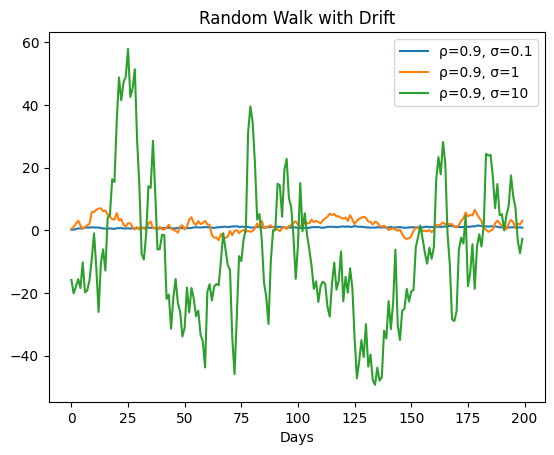

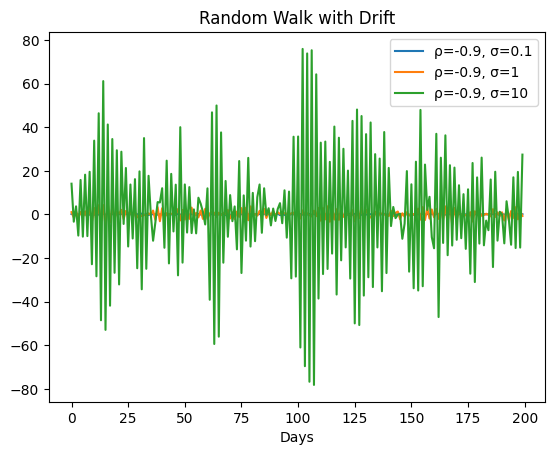

In [25]:
np.random.seed(42)
days = 200
mu = 0.1
sigma = [0.1, 1, 10]

#Strong positive autocorrelation
rho = 0.9
for ss in sigma:
    r = np.zeros(days)
    eps = np.random.normal(0, 1, days)
    ret = random_walk(ss, rho, r, mu, eps)
    plt.plot(ret, label=f"ρ={rho}, σ={ss}")
plt.xlabel("Days")
plt.title("Random Walk with Drift")
plt.legend()
plt.show()


#Strong negative autocorrelation
rho = -0.9
for ss in sigma:
    r = np.zeros(days)
    eps = np.random.normal(0, 1, days)
    ret = random_walk(ss, rho, r, mu, eps)
    plt.plot(ret, label=f"ρ={rho}, σ={ss}")
plt.xlabel("Days")
plt.title("Random Walk with Drift")
plt.legend()
plt.show()

The volatility parameter causes increased variance in the process leading to large spikes for larger sigma. When $\rho$ is positive there is more persistence in the process, causing large shocks to delay mean reversion. The negative $\rho$ causes rapid mean reversion as any values in the process are large retained in absolute value but their sign is switched. 

### 2.

The sample autocorrelation for a series $\{x_t\}$ at a lag j is:

$$\hat{\rho_j} = \frac{\sum_{t=j+1}^T (x_t-\bar{x})(x_{t-j}-\bar{x})}{\sum_{t=1}^T (x_t-\bar{x})^2}$$
for $0\leq j\leq T-1$ and $\bar{x}$ are the sample means. 

The asymptotic standard error of a sample autocorrelation estimator is given by:
$$SE(\hat{\rho}) \approx \frac{1-\rho^2}{\sqrt{T}}$$

Using this equation we can get an estimator of the sample as done below.

In [26]:
def compute_rt(T, rho, mu, sigma):
    epsilon = np.random.normal(0, 1, T)
    rt = np.zeros(T)

    rt[0] = mu / (1 - rho)

    for ii in range(1, T):
        rt[ii] = rho * rt[ii - 1] + mu + sigma * epsilon[ii]
    return rt

def sample_autocorrelation(r, T, num_lags):
    ACF = np.ones(num_lags + 1)
    r_centered = r - np.mean(r)
    
    denom = np.sum(r_centered ** 2)
    for lag in range(1, num_lags + 1):
        num = np.sum(r_centered[lag:] * r_centered[:-lag])
        
        ACF[lag] = num / denom
    
    return ACF

def plots(mean_ACF, finite_se, asymptotic_se, lags, T):

    plt.bar(lags, mean_ACF)
    plt.title(f'Mean ACF across {T} simulations, with ρ = {rho}')
    plt.xlabel('Lags')
    plt.show()

    plt.plot(lags, finite_se, label = 'Finite Sample SE')
    plt.plot(lags, asymptotic_se, label = 'Asymptotic Variance')
    plt.title(f'Finite vs Asymptotic SEs across {T} simulations, with ρ = {rho}')
    plt.xlabel('Lags')
    plt.legend()
    plt.show()

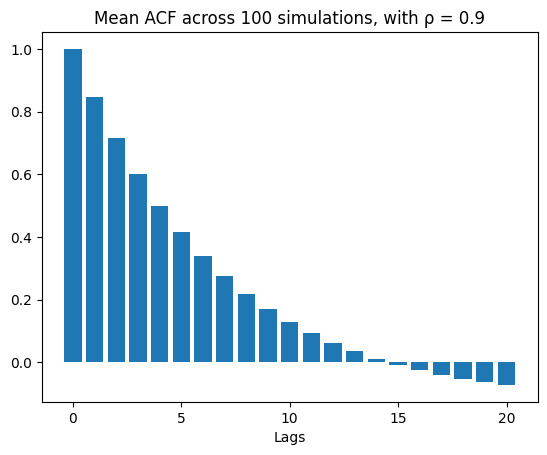

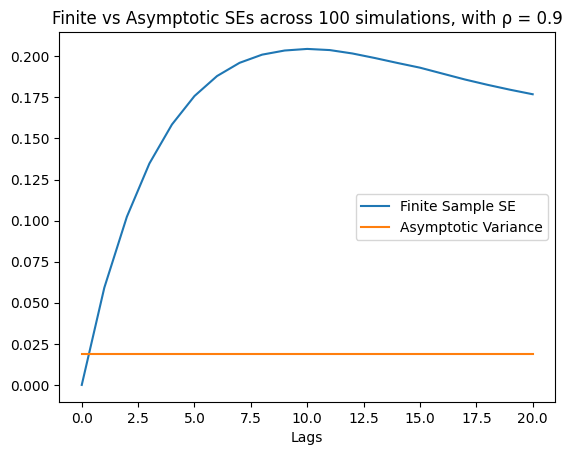

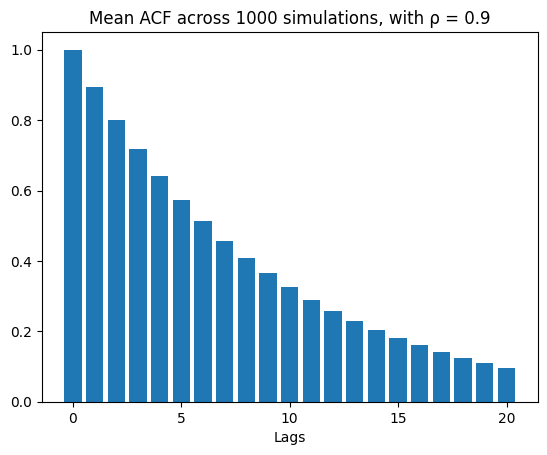

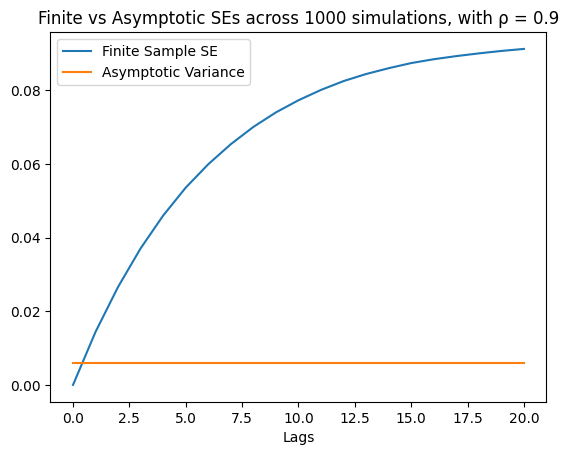

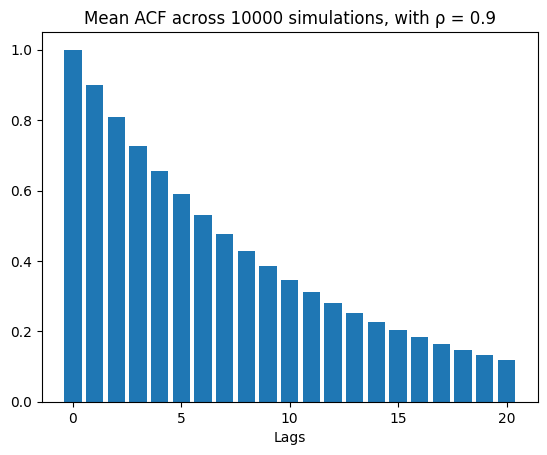

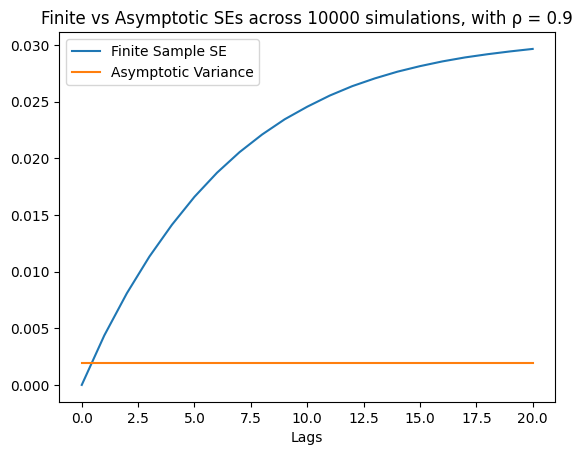

In [ ]:
np.random.seed(42)
N = 10000
T = [100, 1000, 10000]
num_lags = 20
rho = 0.9 #switch to -0.9
sigma = 10
lags = np.arange(num_lags + 1)

rt_pos = {}

mean_ACF_pos = {}
finite_se_pos = {}
asymptotic_se_pos = {}


for tt in T: #observations
    ACFs = np.zeros((N, num_lags + 1))

    for nn in range(N): #simulations
        rt_pos[tt] = compute_rt(tt, rho, mu, sigma)
        sample_ACF = sample_autocorrelation(rt_pos[tt], tt, num_lags)
        ACFs[nn,] = sample_ACF

    mean_ACF_pos[tt] = np.mean(ACFs, axis = 0)
    finite_se_pos[tt] = np.std(ACFs, axis = 0)
    asymptotic_se_pos[tt] = [(1 - rho**2)/np.sqrt(tt) for _ in range(num_lags + 1)]

    plots(mean_ACF_pos[tt], finite_se_pos[tt], asymptotic_se_pos[tt], lags, tt)

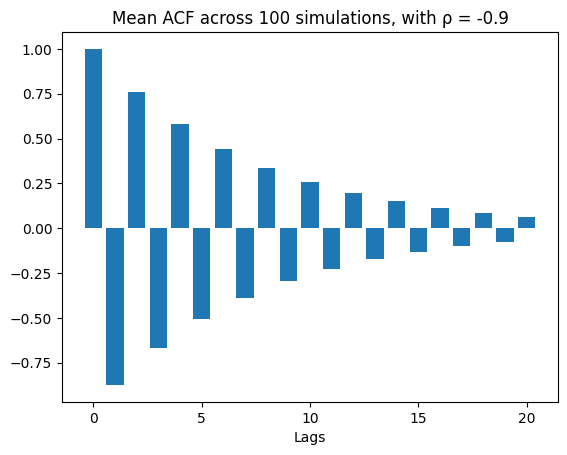

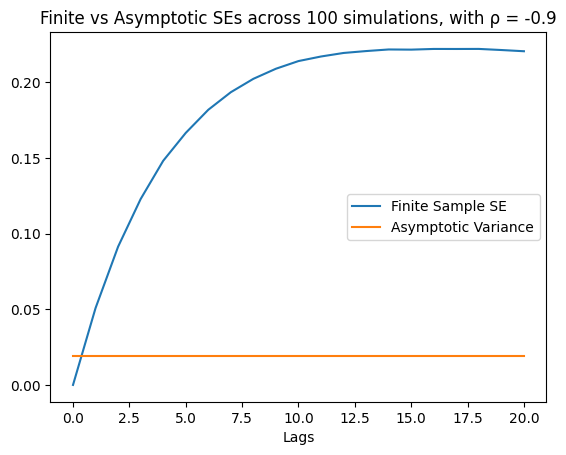

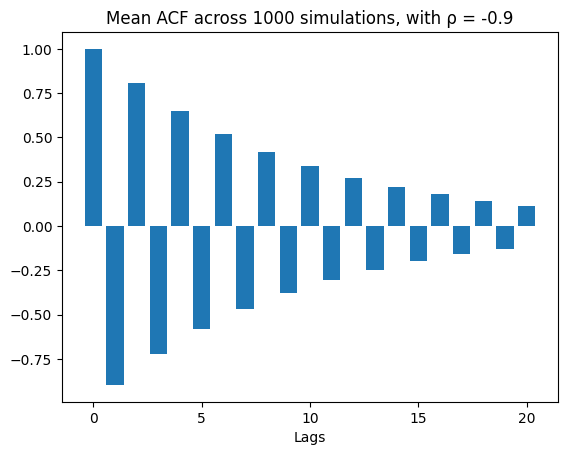

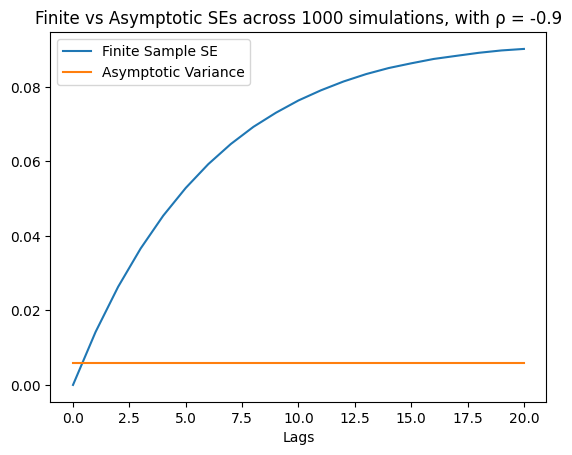

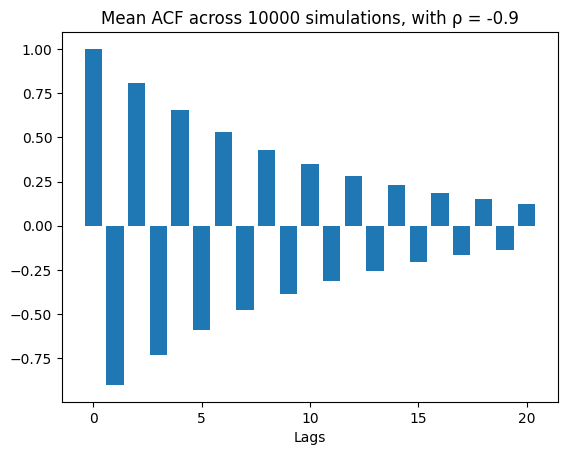

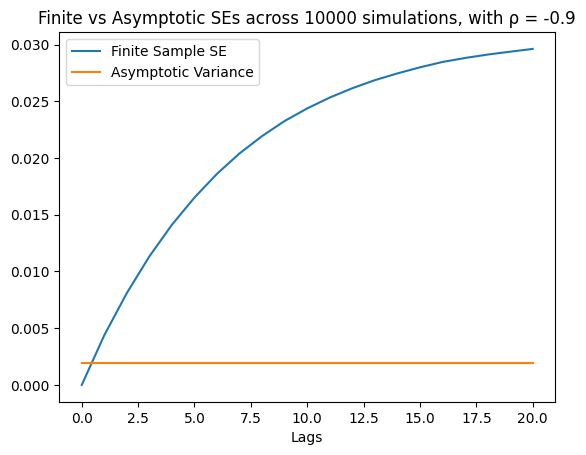

In [28]:
rho = -0.9 

rt_neg = {}

mean_ACF_neg = {}
finite_se_neg = {}
asymptotic_se_neg = {}


for tt in T:
    ACFs = np.zeros((N, num_lags + 1))

    for nn in range(N):
        rt_neg[tt] = compute_rt(tt, rho, mu, sigma)
        sample_ACF = sample_autocorrelation(rt_neg[tt], tt, num_lags)
        ACFs[nn,] = sample_ACF

    mean_ACF_neg[tt] = np.mean(ACFs, axis = 0)
    finite_se_neg[tt] = np.std(ACFs, axis = 0)
    asymptotic_se_neg[tt] = [(1 - rho**2)/np.sqrt(tt) for _ in range(num_lags + 1)]

    plots(mean_ACF_neg[tt], finite_se_neg[tt], asymptotic_se_neg[tt], lags, tt)

In [29]:
import statsmodels.api as sm

In [30]:
def OLS(rt):
    Y = rt[1:]
    X = rt[:-1]
    X = sm.add_constant(X)
    model = sm.OLS(Y,X)
    results = model.fit()
    hac_results = results.get_robustcov_results(cov_type = "HAC", maxlags = num_lags)
    return results.params, hac_results

def OLS_df(rt, T):
    mu_vals = list()
    mu_se = list()
    rho_vals = list()
    rho_se = list()
    for tt in T:
        ols = OLS(rt[tt])
        mu_vals.append(ols[0][0])
        rho_vals.append(ols[0][1])
        mu_se.append(ols[1].bse[0])
        rho_se.append(ols[1].bse[1])
    df = pd.DataFrame({
    "mu": mu_vals,
    "mu_se": mu_se,
    "rho": rho_vals,
    "rho_se": rho_se,
    "T": T
    })
    return df

In [31]:
df_pos = OLS_df(rt_pos, T)
df_neg = OLS_df(rt_neg, T)


In [32]:
df_pos

,mu,mu_se,rho,rho_se,T
0,0.393378,1.151761,0.971844,0.020822,100
1,0.322458,0.331603,0.899671,0.013217,1000
2,0.152736,0.098558,0.899491,0.004183,10000


In [33]:
df_neg

,mu,mu_se,rho,rho_se,T
0,1.621741,0.724449,-0.944844,0.043532,100
1,0.340301,0.348828,-0.902084,0.014919,1000
2,0.041397,0.101465,-0.899741,0.004281,10000


###  Do you find any bias? Why is it biased?


There is finite sample bias which is visibile in the T=100 samples. The $\hat{\rho}$ estimate is far away from what we know the real $\rho$ to be. The estimate converges to the real rho in the larger samples (T=1000 and T=10,000), showing that the bias is only in smaller samples, like T=100. The estimate is biased because the autocorrelation in the model causes $r_{t-1}$ to be correlated with previous shocks $\epsilon$.